# keras-hexagdly CNN example

Port of HexagDLy's own `hexagdly_cnn_example.ipynb`: a small CNN classifies hexagonal toy shapes. The API mirrors PyTorch HexagDLy's -- `keras_hexagdly.Conv2d`/`MaxPool2d` are ordinary Keras layers, so the model is an ordinary `keras.Sequential` trained with `model.fit`.

In [1]:
%matplotlib inline
import numpy as np
import keras
import keras_hexagdly as hgly

from toy_data import ToyDataset, toy_hex_image
from hexplot import plot_hextensor

First, hexagonal image data is created via `ToyDataset`. In this example, hexagonally sampled images with different shapes at random positions are generated. The training and validation sets contain 128 and 32 images of each shape respectively.
Possible shapes: `['small_hexagon', 'medium_hexagon', 'snowflake_1', 'snowflake_2', 'snowflake_3', 'snowflake_4', 'double_hex']`.

In [2]:
shape_list = ['snowflake_2', 'snowflake_3', 'snowflake_4', 'double_hex']
H, W = 20, 20

train_data = ToyDataset(shape_list, 128, H, W).create(seed=0)
val_data = ToyDataset(shape_list, 32, H, W).create(seed=1)
x_train, y_train = train_data.to_arrays()
x_val, y_val = val_data.to_arrays()
print('train:', x_train.shape, ' val:', x_val.shape)

train: (512, 20, 20, 1)  val: (128, 20, 20, 1)


A few example images from the validation set:

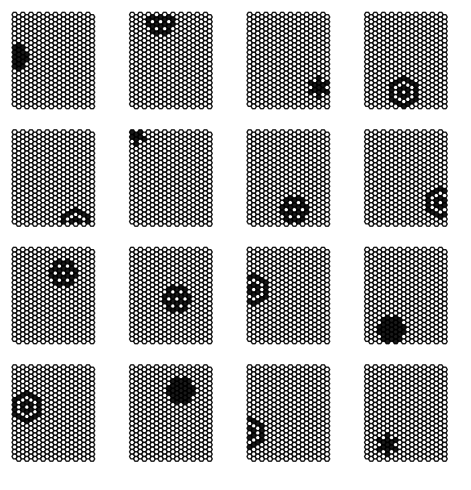

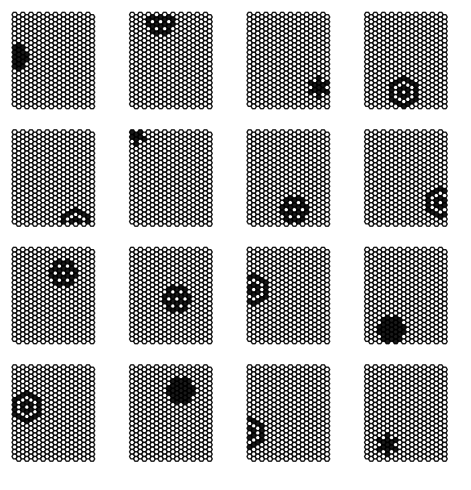

In [3]:
plot_hextensor(x_val[:16], figname='val_examples')

Next, a small CNN is built with `keras_hexagdly`'s convolution and pooling layers -- a plain `keras.Sequential`, just like any other Keras model:

In [4]:
model = keras.Sequential([
    keras.layers.Input(shape=(H, W, 1)),
    hgly.Conv2d(out_channels=16, kernel_size=2, stride=1),
    keras.layers.ReLU(),
    hgly.MaxPool2d(kernel_size=1, stride=2),
    hgly.Conv2d(out_channels=32, kernel_size=2, stride=1),
    keras.layers.ReLU(),
    hgly.MaxPool2d(kernel_size=1, stride=2),
    keras.layers.Flatten(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(shape_list)),
])
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2d)                 │ (None, 20, 20, 16)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool2d (MaxPool2d)          │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2d)               │ (None, 10, 10, 32)     │         9,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool2d_1 (MaxPool2d)        │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,844 (140.02 KB)

 Trainable params: 35,844 (140.02 KB)

 Non-trainable params: 0 (0.00 B)

The training and validation data are loaded into the model and the CNN is trained for a few epochs:

In [5]:
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=25, verbose=0)
print('final validation accuracy:', round(history.history['val_accuracy'][-1], 3))

final validation accuracy: 0.992


Looking at the learning curves, the model clearly learns to distinguish the different shapes:

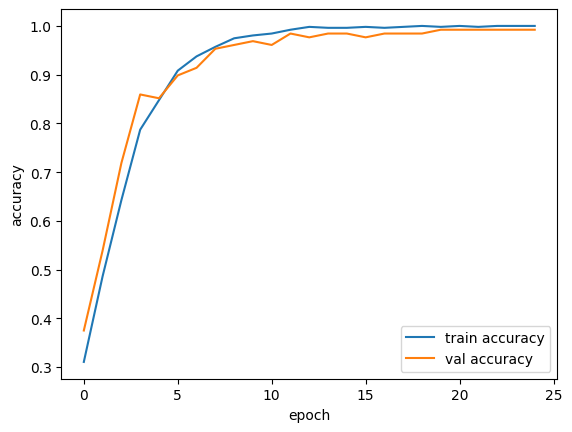

In [6]:
import matplotlib.pyplot as plt
plt.figure('learning_curves')
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend();

To probe the model in detail, a test image is created with a hexagonal shape at a given position. By changing `px`/`py` the shape can be moved to an arbitrary position; the trained CNN's prediction should not depend on it, since the hexagonal convolution preserves translational invariance on the hex grid.

1.    snowflake_3   99.9% <-- correct
2.    snowflake_2    0.1%
3.    snowflake_4    0.0%
4.     double_hex    0.0%


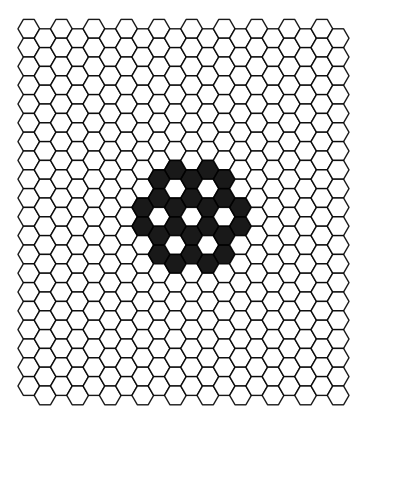

In [7]:
test_shape = 'snowflake_3'
testimage = toy_hex_image(test_shape, H, W, px=10, py=10)
plot_hextensor(testimage, figname='test_shape')

logits = model(keras.ops.convert_to_tensor(testimage))
probs = keras.ops.convert_to_numpy(keras.ops.softmax(logits))[0]
order = np.argsort(-probs)

for rank, idx in enumerate(order):
    tag = ' <-- correct' if shape_list[idx] == test_shape and rank == 0 else ''
    print(f'{rank + 1}. {shape_list[idx]:>14s}  {100 * probs[idx]:5.1f}%{tag}')